In [1]:
# THIS CODE USES NUMPY; FOR FEWER THAN 500 GRIDPOINTS
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit, prange

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation
import ipywidgets as widgets
from IPython.display import display

print("Fin")

Fin


In [2]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 250 * 10**5 # In timesteps of dt
gridpoints = 128 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 9E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2 = 1.0 / (dx * dx)

# Establishes constants
K = 1.0E6 # Units: nm^5 
M = 1 # Units: (nm s)^-1
B2 = 2190 # Units: nm^3
vb = 1.66 # Units: nm^3
kB = 1.314E-23 * 0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
dHa = -42000 # Units: cal/mol 
dS1 = 1.84 * np.log(Na) # Units: cal/mol K
dS0 = -120 # Units: cal/mol K at 1M NaCl
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 # Number of saved values

Da = vb * np.exp(-(dHa - T * (dS0 + dS1)) / (mol * kB * T))
Db = Da

print("Fin")

Fin


In [3]:
# Initializes array of density values
np.random.seed(7) # Opens a random number generator instance, seed 7

rho = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=(gridpoints, gridpoints))) # Creates rho values around the mean with slight randomness
rho = np.maximum(rho, 1.E-10) # Prevents negative densities

initial_mass = np.sum(rho)
n = rho.shape[0]

@jit(nopython=True, cache=False) # Converts the given function into machine code (optimization) and tries to parallelize
def laplacian_2d(function_array):
    """
    Computes the 2D Laplacian of a function, given an array representing that function
    """
    # Note: np.roll with axis= is unsupported in Numba nopython mode
    # Periodic boundary conditions are implemented via explicit modular indexing
    result = np.empty_like(function_array)
    for i in range(n):
        for j in range(n):
            result[i, j] = (
                function_array[i, (j+1) % n] - 2.0 * function_array[i, j] + function_array[i, (j-1) % n] +  # x-axis neighbors
                function_array[(i+1) % n, j] - 2.0 * function_array[i, j] + function_array[(i-1) % n, j]    # y-axis neighbors
            ) * inv_dx2
    return result


@jit(nopython=True, parallel=True, cache=False) # Converts the given function into machine code (optimization) and tries to parallelize
def compute_step_single(rho):
    # Total chemical potential (with floored rho, Xa)
    beta_mu_total = np.empty_like(rho)
    for i in prange(n):
        for j in range(n):
            rho_ij = rho[i, j]
            lap_rho = (
                rho[i, (j+1) % n] - 2.0 * rho_ij + rho[i, (j-1) % n] +  # x-axis neighbors
                rho[(i+1) % n, j] - 2.0 * rho_ij + rho[(i-1) % n, j]     # y-axis neighbors
            ) * inv_dx2
            beta_mu_total[i, j] = (2.0 * B2 * rho_ij + np.log(rho_ij) +                                   # beta mu_ref
                                   valence * np.log((-1 + np.sqrt(1 + 4 * 4 * rho_ij * Da)) /             # beta mu_b
                                   (2 * 4 * rho_ij * Da)) -
                                   K * lap_rho)                                                             # beta mu_int

    # Finds the 2D Laplacian of beta mu total
    laplacian_2d_mu = laplacian_2d(beta_mu_total)

    # Updates the density explicitly: rho(t+dt) = rho(t) + dt * M laplacian (beta mu_total)
    return dt * M * laplacian_2d_mu

print("Fin")

Fin


In [4]:
# Initializes arrays for saving rho
num_saves = duration // save_interval + 1
rho_total_array = np.zeros((num_saves, gridpoints, gridpoints)) # Third dimension added for 2D grid
rho_total_array[0] = rho
save_index = 1

# Tracks the mass over time to ensure conservation
mass_history = []
time_history = []


for step in range(duration):

    # Iterates to find new value of rho
    rho += compute_step_single(rho)

    # Adds the new density to the array of densities + checks mass conservation every 10^6 steps
    if step % (save_interval) == 0:
        rho_total_array[save_index] = rho
        save_index += 1

        total_mass = np.sum(rho)

        mass_history.append(total_mass)
        time_history.append(step * dt)

        rho = np.maximum(rho, floor)

        print(f"Progress: {(step/(save_interval))} out of {duration/(save_interval)}")

Progress: 0.0 out of 250.0
Progress: 1.0 out of 250.0
Progress: 2.0 out of 250.0
Progress: 3.0 out of 250.0
Progress: 4.0 out of 250.0
Progress: 5.0 out of 250.0
Progress: 6.0 out of 250.0
Progress: 7.0 out of 250.0
Progress: 8.0 out of 250.0
Progress: 9.0 out of 250.0
Progress: 10.0 out of 250.0
Progress: 11.0 out of 250.0
Progress: 12.0 out of 250.0
Progress: 13.0 out of 250.0
Progress: 14.0 out of 250.0
Progress: 15.0 out of 250.0
Progress: 16.0 out of 250.0
Progress: 17.0 out of 250.0
Progress: 18.0 out of 250.0
Progress: 19.0 out of 250.0
Progress: 20.0 out of 250.0
Progress: 21.0 out of 250.0
Progress: 22.0 out of 250.0
Progress: 23.0 out of 250.0
Progress: 24.0 out of 250.0
Progress: 25.0 out of 250.0
Progress: 26.0 out of 250.0
Progress: 27.0 out of 250.0
Progress: 28.0 out of 250.0
Progress: 29.0 out of 250.0
Progress: 30.0 out of 250.0
Progress: 31.0 out of 250.0
Progress: 32.0 out of 250.0
Progress: 33.0 out of 250.0
Progress: 34.0 out of 250.0
Progress: 35.0 out of 250.0
Pr

Traceback (most recent call last):
  File "/home/nehadesigar/my_env/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_241202/631326826.py", line 15, in <module>
    rho += compute_step_single(rho)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nehadesigar/my_env/lib/python3.12/site-packages/numba/core/serialize.py", line 30, in _numba_unpickle
    def _numba_unpickle(address, bytedata, hashed):
    
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/nehadesigar/my_env/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 2223, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nehadesigar/my_env/lib/python3.12/site-packages/IPython/core/ultratb.py", line 1228, in structured_traceback
    ret

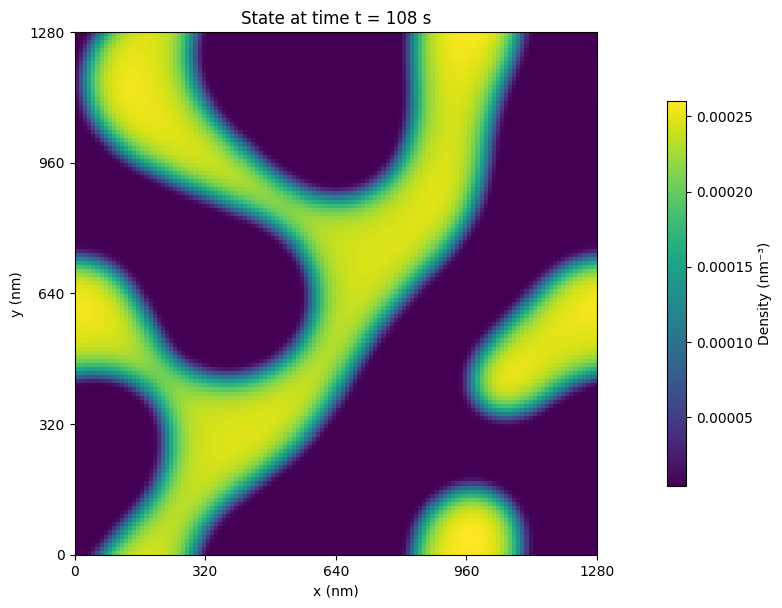

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

vmin, vmax = rho.min(), rho.max()
t_final = (save_index - 1) * save_interval * dt

im = ax.imshow(rho, origin='lower', cmap='viridis',
               vmin=vmin, vmax=vmax,
               extent=[0, grid_length, 0, grid_length])
fig.colorbar(im, ax=ax, label="Density (nm⁻³)", shrink = 0.5, pad = 0.1)
ax.set_title(f"State at time t = {t_final:.0f} s")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_xticks([0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length])
ax.set_yticks([0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length])


plt.tight_layout()
plt.savefig("rho_final.png", dpi=150)
plt.show()

In [12]:
def find_perimeter(rho):

    # Creates binary array: 0 for pixel in dilute phase, 1 for pixel in dense phase
    threshold = (rho.max() + rho.min()) / 2
    binary_mask = (rho >= threshold).astype(int)

    # Pads with periodic boundaries
    padded = np.pad(binary_mask, pad_width=1, mode='wrap')

    # Checks to see if each pixel has at least one dilute neighbor
    neighbor_sum = (padded[:-2, 1:-1] + padded[2:,  1:-1] + padded[1:-1, :-2] + padded[1:-1, 2:])

    # Finds dense pixels with dilute neighbors + counts
    interface_mask = (binary_mask == 1) & (neighbor_sum < 4)
    interface_count = int(interface_mask.sum())

    return binary_mask, interface_mask, interface_count


def calc_free_energy(rho, Xa, v0 = 1):
    '''
    Finds free energy of a system using F = integral_V [ f({rho_i}) + K/2 sum_i (gradient rho)^2 ] dV

    Using f_ref = rho * log(v_0 * rho) - rho + B2 * rho^2 + {sum_i [rho_i log(rho_i/rho_tot)]}

    The last term will always be 0 for a 1-component system (log 1 = 0), so it not included here

    Using f_b = rho_A * valence * (log(Xa) + (1-Xa)/2)
    
    Note that this will vary by mixture-- eq shown is for AAAA only
    '''

    # Floors rho to prevent error
    rho_floored = np.maximum(rho, floor)

    # Finds f_ref and f_b
    f_ref = rho_floored * np.log(v0 * rho_floored) - rho_floored + B2 * rho_floored**2
    f_b = rho_floored * 4 * (np.log(Xa) + (1-Xa)/2)

    # Finds the local free energy at each point (f{rho_i})
    f_local = f_ref + f_b
    
    # Calculates the gradient term K/2 * (gradient rho)^2
    grad_x, grad_y = np.gradient(rho)
    f_gradient = 0.5 * K * (grad_x**2 + grad_y**2)
    
    # Total free energy density
    f_total = f_local + f_gradient
    
    # Integrate over volume in 1D (multiply by dx and sum)
    F_total = np.trapezoid(np.trapezoid(f_total, dx=dx, axis= 1), axis = 0)
    
    return F_total



In [13]:
#Finds interfacial area for rho and floors it
binary_mask, interface_mask, interface_count = find_perimeter(rho)
interfacial_area = interface_count * dx
rho_floored = np.maximum(rho, floor)

# Extracts dilute/dense phase densities and creates homogenous systems
rho_dilute = np.min(rho_floored) 
rho_dense = np.max(rho_floored)

rho_dilute_system = np.full((gridpoints, gridpoints), rho_dilute)
rho_dense_system = np.full((gridpoints, gridpoints), rho_dense)

# Finds Xa for dilute, dense, and coex
CaDa = 4*rho_floored*Da
Xa = (-1 + np.sqrt(1 + 4 * CaDa)) / (2 * CaDa)
Xa_final_coex = np.maximum(Xa, floor) 

CaDa_dilute = 4*rho_dilute_system*Da
CaDa_dilute_floored = np.maximum(CaDa_dilute, floor)
Xa_final_dilute = (-1 + np.sqrt(1 + 4 * CaDa_dilute_floored)) / (2 * CaDa_dilute_floored)

CaDa_dense = 4*rho_dense_system*Da
CaDa_dense_floored = np.maximum(CaDa_dense, floor)
Xa_final_dense = (-1 + np.sqrt(1 + 4 * CaDa_dense_floored)) / (2 * CaDa_dense_floored)

# Finds free energy of dilute, dense, and coexisting systems
F_dilute = calc_free_energy(rho_dilute_system, Xa_final_dilute)
F_dense = calc_free_energy(rho_dense_system, Xa_final_dense)
F_coex = calc_free_energy(rho_floored, Xa_final_coex)

surface_tension = (F_coex - F_dilute - F_dense) / (interfacial_area)
print(f"The surface tension is {surface_tension:.6e} for T = {T} in a 2D system with 1 component, initialized with a uniform distribution")

The surface tension is 6.982287e-02 for T = 303.15 in a 2D system with 1 component, initialized with a uniform distribution
